<xarray.Dataset> Size: 206MB
Dimensions:                (depth: 1100, time: 1299)
Coordinates:
  * depth                  (depth) float64 9kB 0.5 1.5 2.5 ... 1.098e+03 1.1e+03
    profile                (time) float64 10kB ...
  * time                   (time) datetime64[ns] 10kB 2023-10-27T08:05:24 ......
Data variables: (12/22)
    longitude              (time) float64 10kB ...
    latitude               (time) float64 10kB ...
    profile_time_start     (time) float64 10kB ...
    profile_time_end       (time) float64 10kB ...
    heading                (depth, time) float64 11MB ...
    pitch                  (depth, time) float64 11MB ...
    ...                     ...
    salinity               (depth, time) float64 11MB ...
    potential_density      (depth, time) float64 11MB ...
    density                (depth, time) float64 11MB ...
    potential_temperature  (depth, time) float64 11MB ...
    profile_index          (depth, time) float64 11MB ...
    profile_direction     

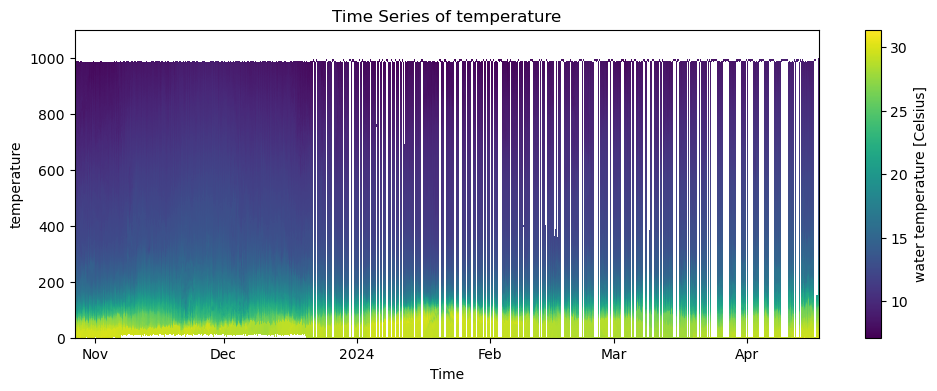

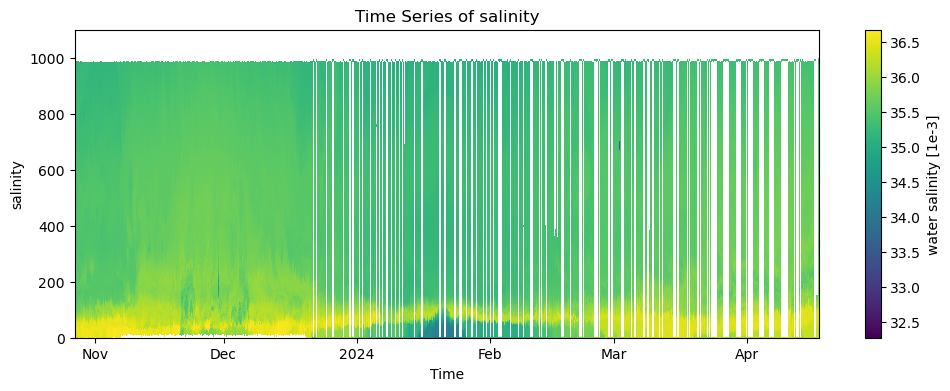

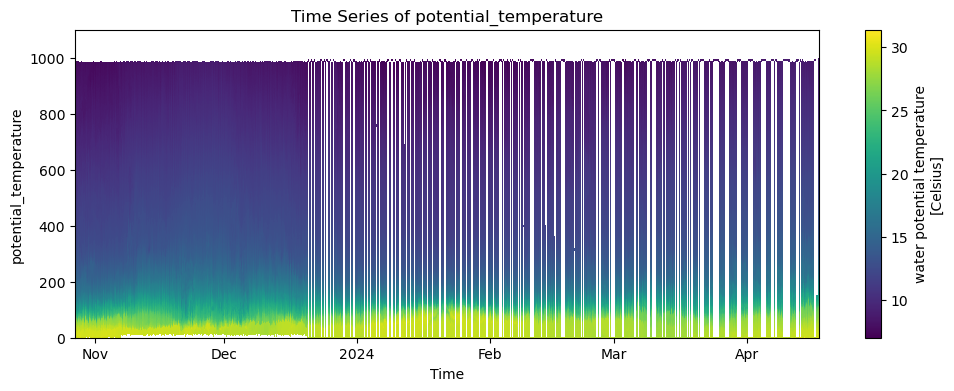

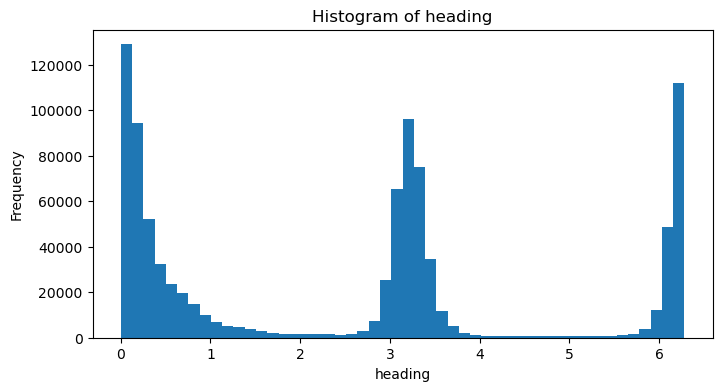

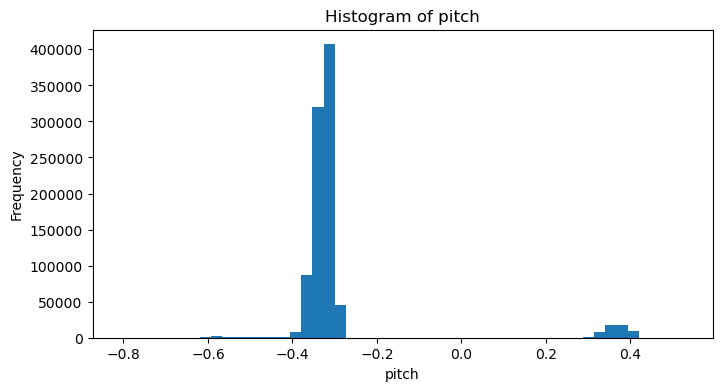

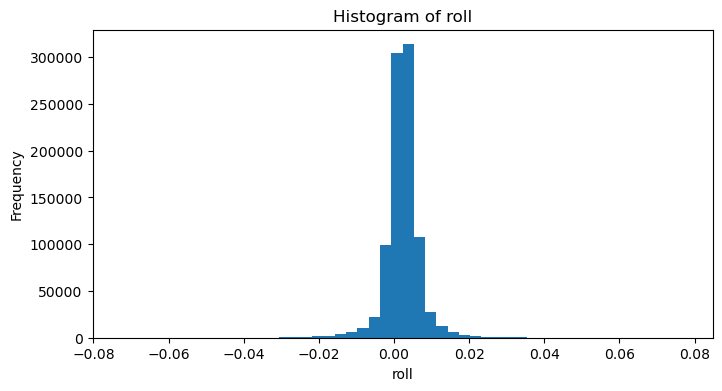

Correlation matrix:
                        temperature  salinity  potential_temperature   heading  \
temperature               1.000000  0.675754               0.999998 -0.024361   
salinity                  0.675754  1.000000               0.675689 -0.050328   
potential_temperature     0.999998  0.675689               1.000000 -0.024396   
heading                  -0.024361 -0.050328              -0.024396  1.000000   
pitch                    -0.189841 -0.159685              -0.189635  0.080894   
roll                     -0.147999 -0.067303              -0.147841 -0.003803   

                          pitch      roll  
temperature           -0.189841 -0.147999  
salinity              -0.159685 -0.067303  
potential_temperature -0.189635 -0.147841  
heading                0.080894 -0.003803  
pitch                  1.000000  0.250007  
roll                   0.250007  1.000000  


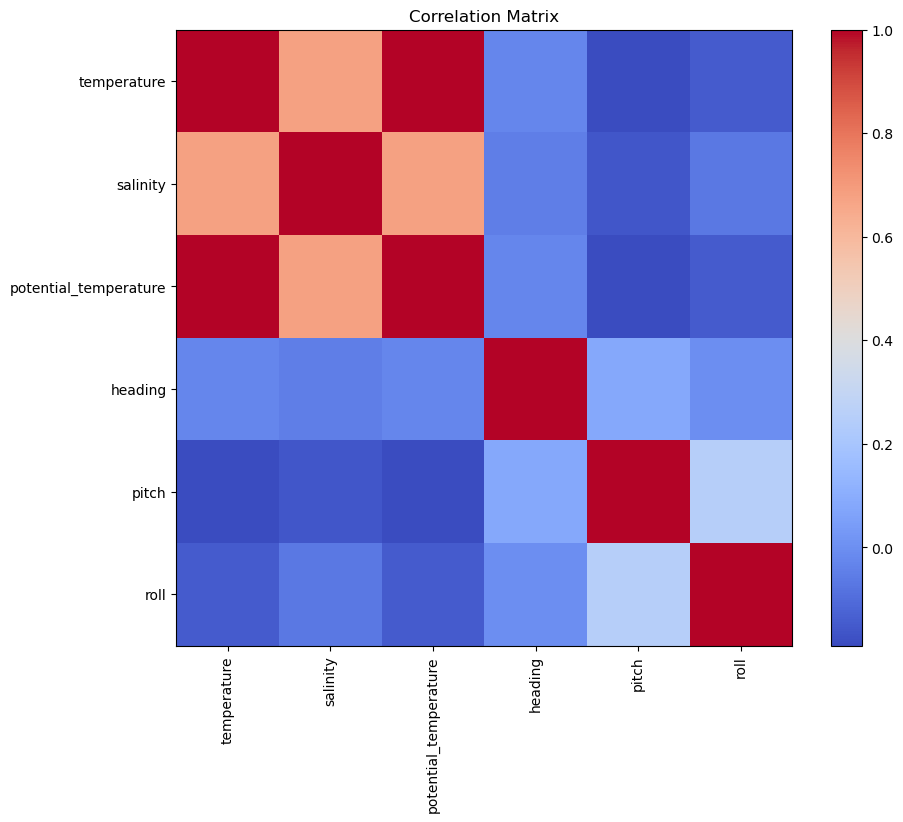

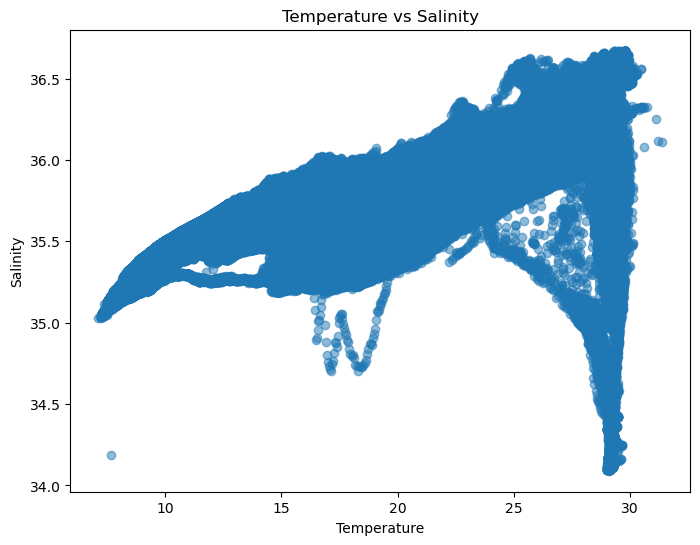

In [1]:
import xarray as xr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# Load NetCDF file using xarray
# file_path = 'path_to_your_glider_data.nc'  # Update with your actual file path

file_path = 'D:\\Data\\glider\\process_1127\\L0-gridfiles\\dfo-rosie713-20190615_grid.nc'  # Example file path, update as needed
ds = xr.open_dataset(file_path)

# Overview of dataset
print(ds)

# List variables and dimensions
print("Variables:", list(ds.data_vars))
print("Dimensions:", list(ds.dims))

# Summary statistics for all variables
summary = ds.to_dataframe().describe()
print(summary)

# Check for missing values
missing = ds.to_dataframe().isnull().sum()
print("Missing values per variable:\n", missing)

# Plot time series for science sensors (example: temperature, salinity)
science_vars = [var for var in ds.data_vars if 'temperature' in var or 'salinity' in var]
for var in science_vars:
    plt.figure(figsize=(12, 4))
    ds[var].plot()
    plt.title(f'Time Series of {var}')
    plt.xlabel('Time')
    plt.ylabel(var)
    plt.show()

# Plot histograms for flight parameters (example: pitch, roll, heading)
flight_vars = [var for var in ds.data_vars if 'pitch' in var or 'roll' in var or 'heading' in var]
for var in flight_vars:
    plt.figure(figsize=(8, 4))
    ds[var].plot.hist(bins=50)
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

# Correlation analysis between science sensors and flight parameters
df = ds.to_dataframe().dropna()
corr = df[science_vars + flight_vars].corr()
print("Correlation matrix:\n", corr)

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.index)
plt.title('Correlation Matrix')
plt.show()

# Scatter plot example: temperature vs salinity
if 'temperature' in ds.data_vars and 'salinity' in ds.data_vars:
    plt.figure(figsize=(8, 6))
    plt.scatter(df['temperature'], df['salinity'], alpha=0.5)
    plt.xlabel('Temperature')
    plt.ylabel('Salinity')
    plt.title('Temperature vs Salinity')
    plt.show()

# Save summary statistics to CSV
summary.to_csv('glider_data_summary.csv')

Dataset Info:
<xarray.Dataset> Size: 206MB
Dimensions:                (depth: 1100, time: 1299)
Coordinates:
  * depth                  (depth) float64 9kB 0.5 1.5 2.5 ... 1.098e+03 1.1e+03
    profile                (time) float64 10kB 1.0 2.0 ... 1.298e+03 1.299e+03
  * time                   (time) datetime64[ns] 10kB 2023-10-27T08:05:24 ......
Data variables: (12/22)
    longitude              (time) float64 10kB 67.49 67.49 67.49 ... 67.05 67.05
    latitude               (time) float64 10kB 11.5 11.5 11.51 ... 16.54 16.54
    profile_time_start     (time) float64 10kB 11.5 11.5 11.51 ... 16.54 16.54
    profile_time_end       (time) float64 10kB 11.5 11.5 11.51 ... 16.54 16.54
    heading                (depth, time) float64 11MB 2.225 0.739 ... nan nan
    pitch                  (depth, time) float64 11MB -0.2653 -0.5311 ... nan
    ...                     ...
    salinity               (depth, time) float64 11MB 36.51 36.52 ... nan nan
    potential_density      (depth, time) f

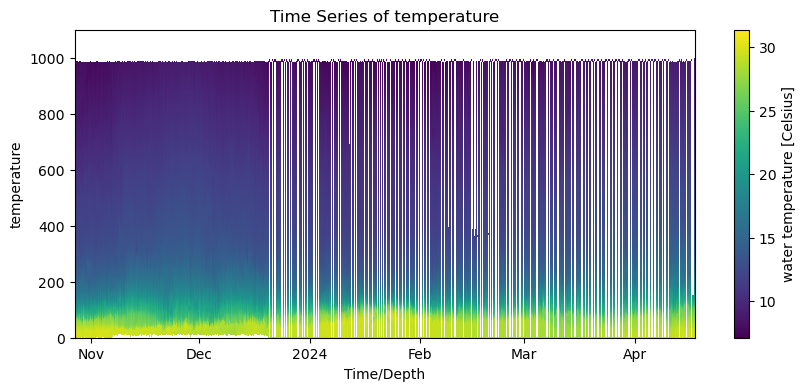

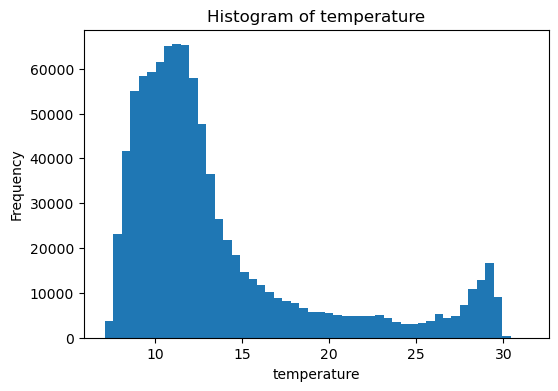

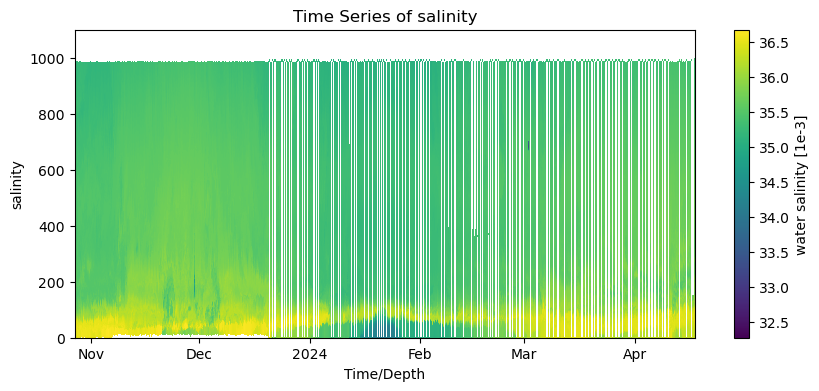

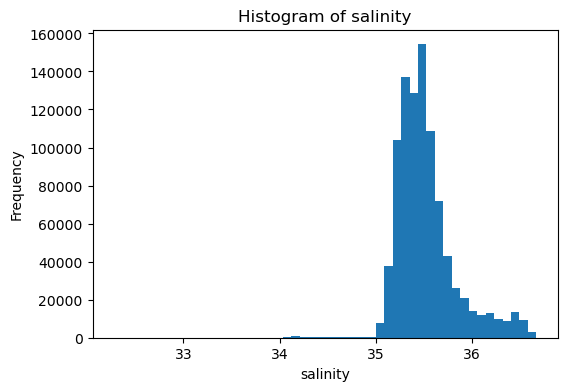

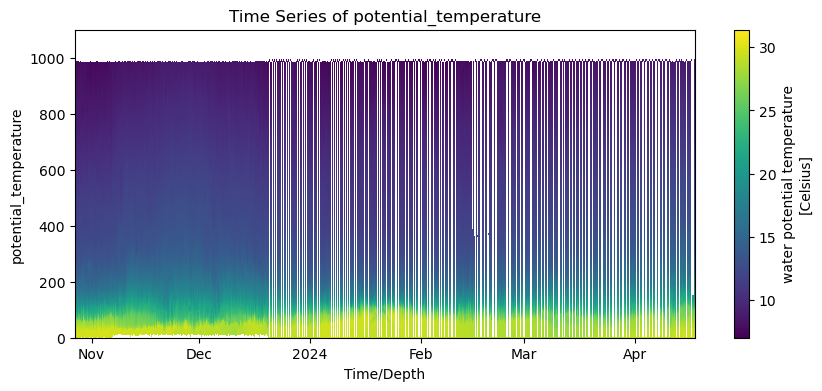

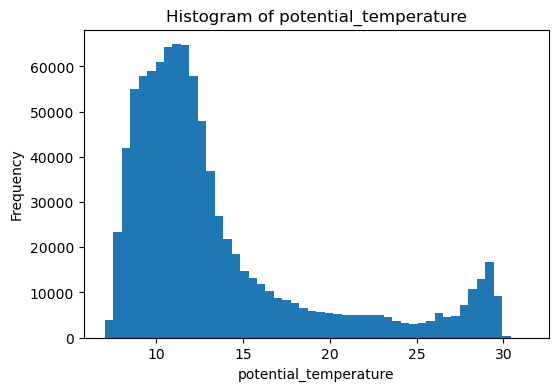


Flight Variables: ['heading', 'pitch', 'roll']


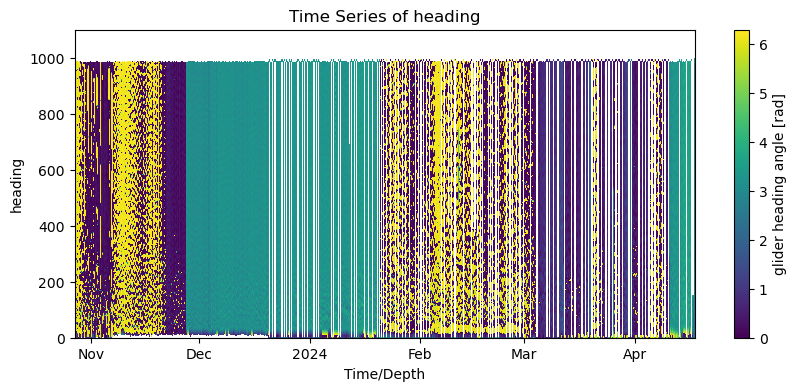

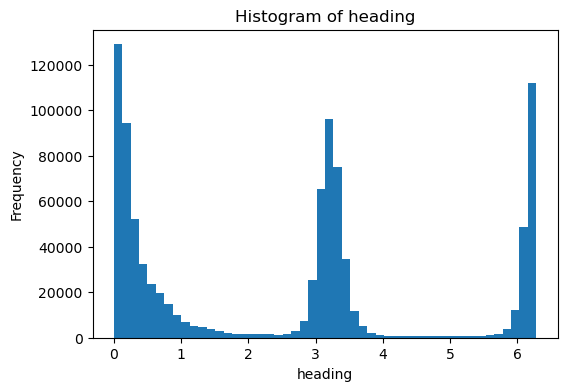

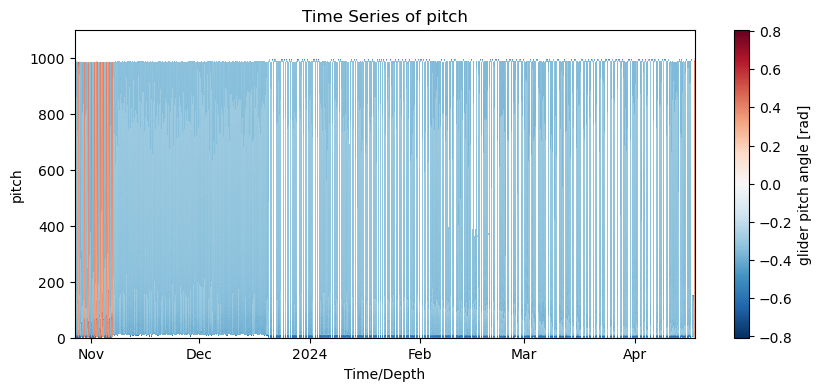

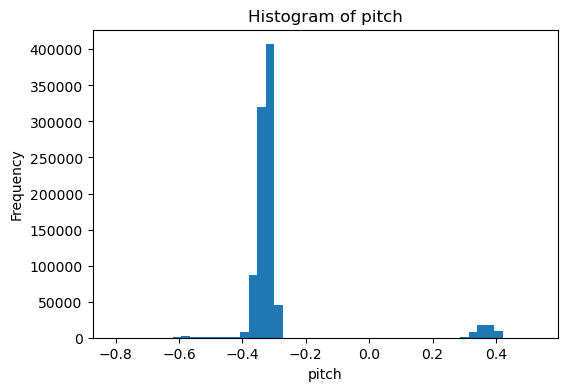

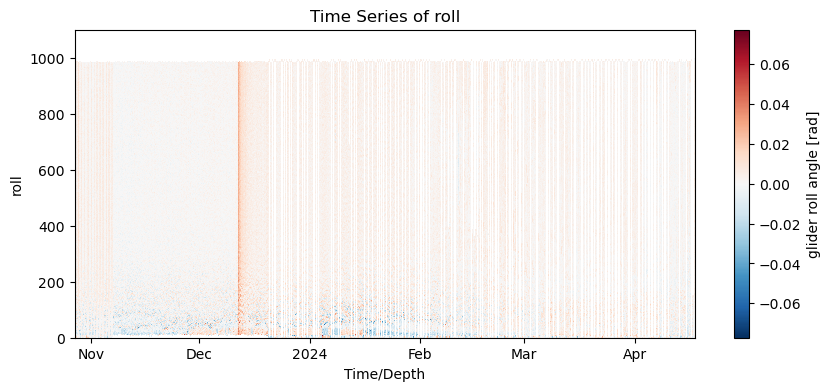

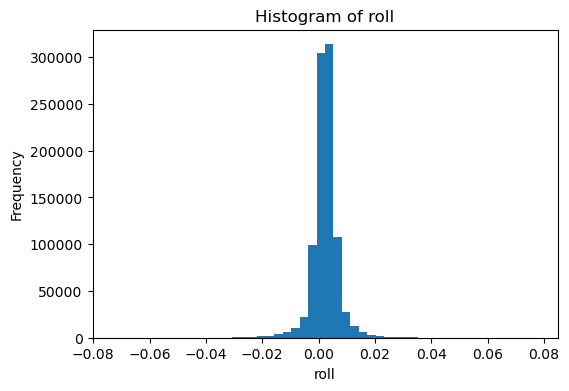


Correlation Matrix (Science & Flight Sensors):
                       temperature  salinity  potential_temperature   heading  \
temperature               1.000000  0.675754               0.999998 -0.024361   
salinity                  0.675754  1.000000               0.675689 -0.050328   
potential_temperature     0.999998  0.675689               1.000000 -0.024396   
heading                  -0.024361 -0.050328              -0.024396  1.000000   
pitch                    -0.189841 -0.159685              -0.189635  0.080894   
roll                     -0.147999 -0.067303              -0.147841 -0.003803   

                          pitch      roll  
temperature           -0.189841 -0.147999  
salinity              -0.159685 -0.067303  
potential_temperature -0.189635 -0.147841  
heading                0.080894 -0.003803  
pitch                  1.000000  0.250007  
roll                   0.250007  1.000000  


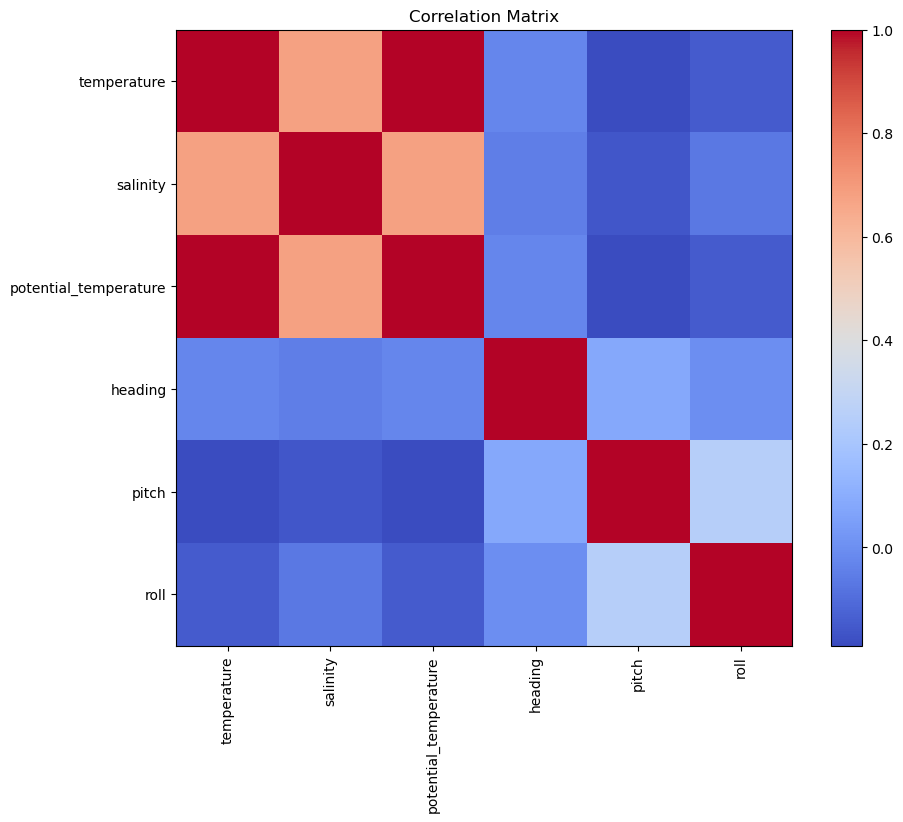

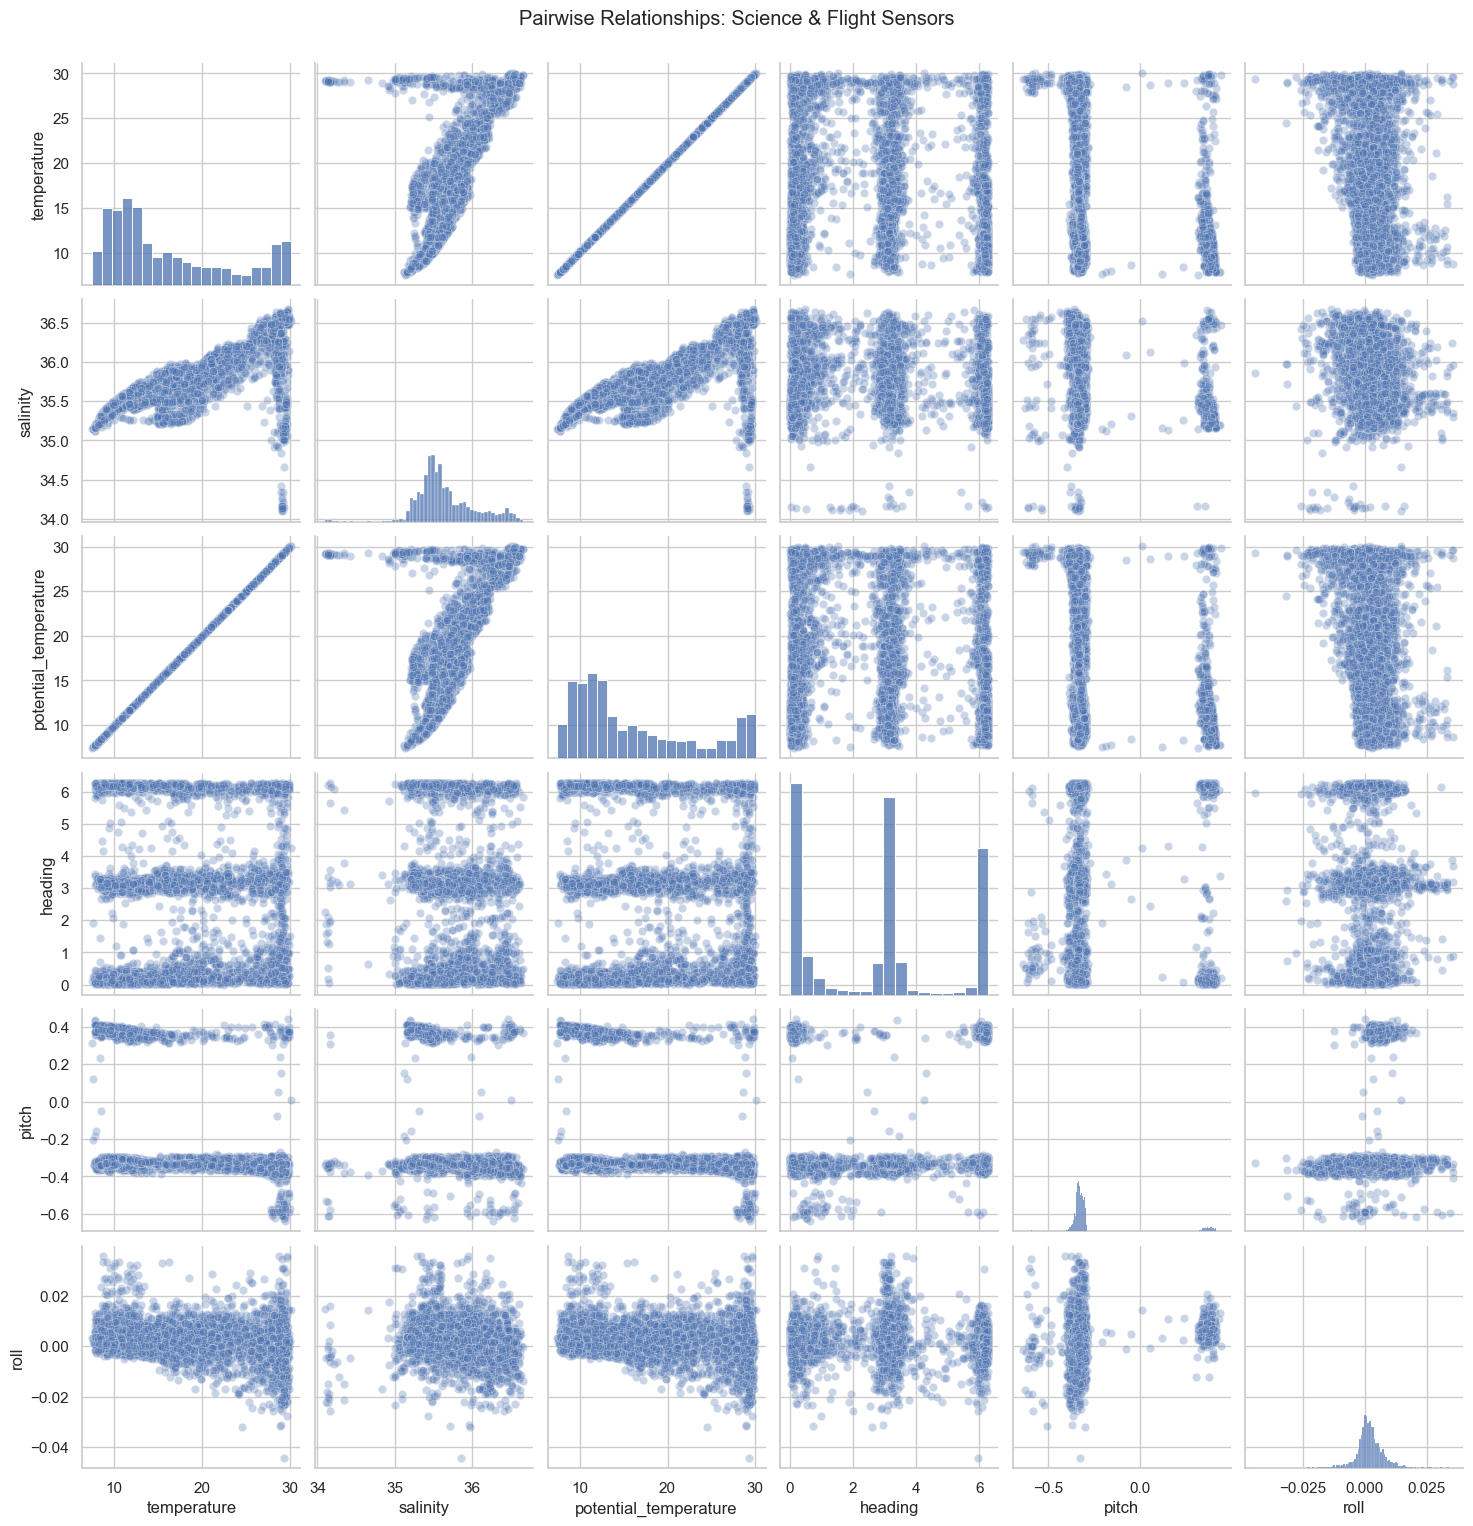

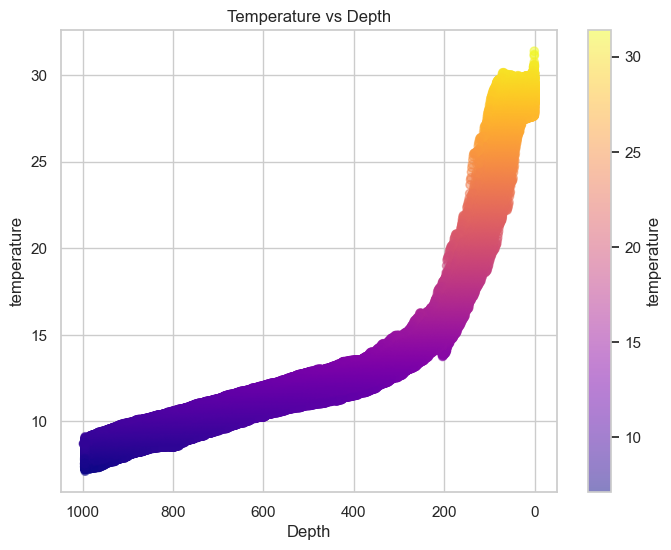

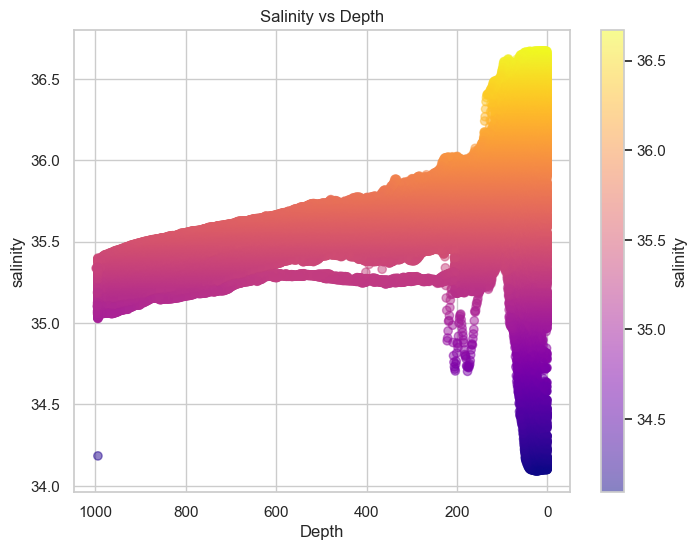

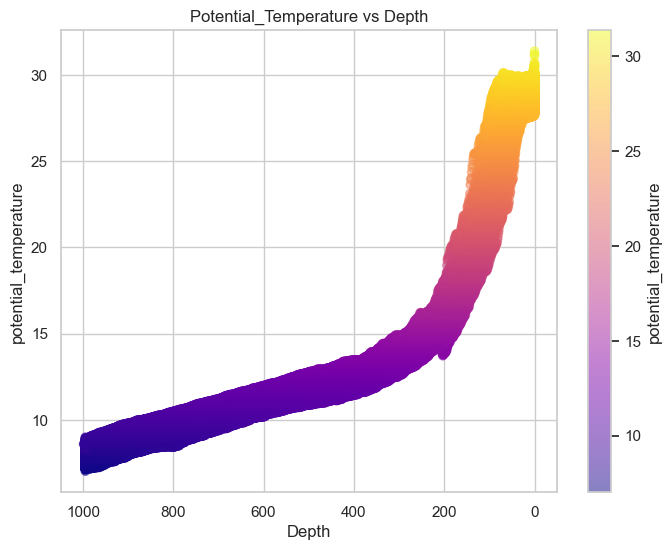

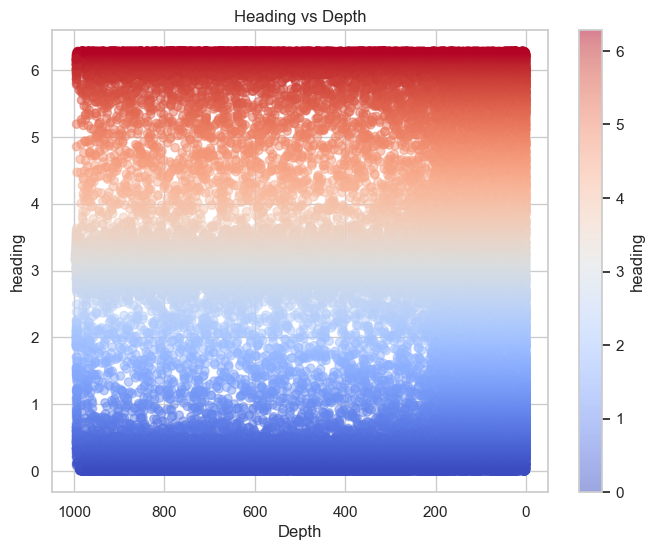

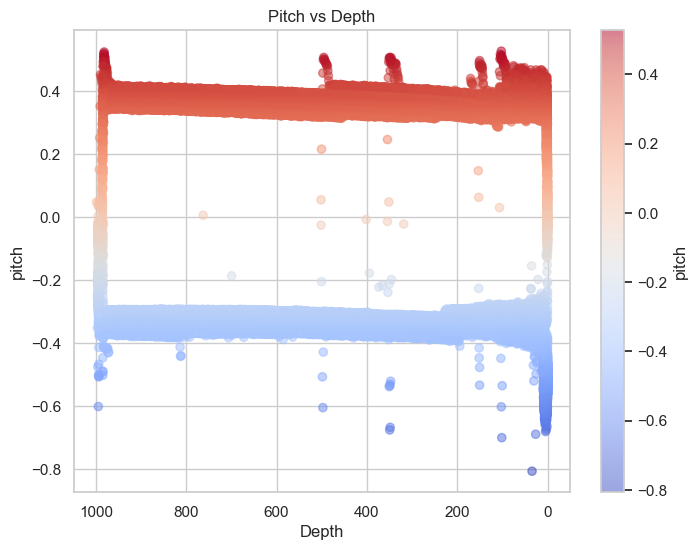

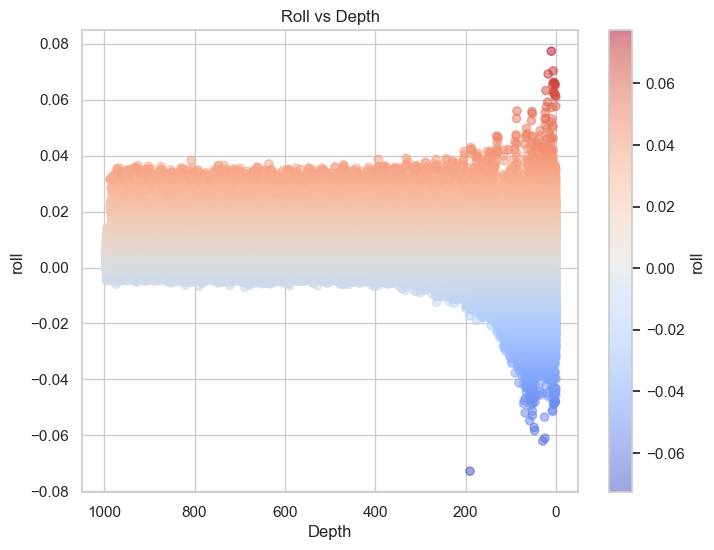

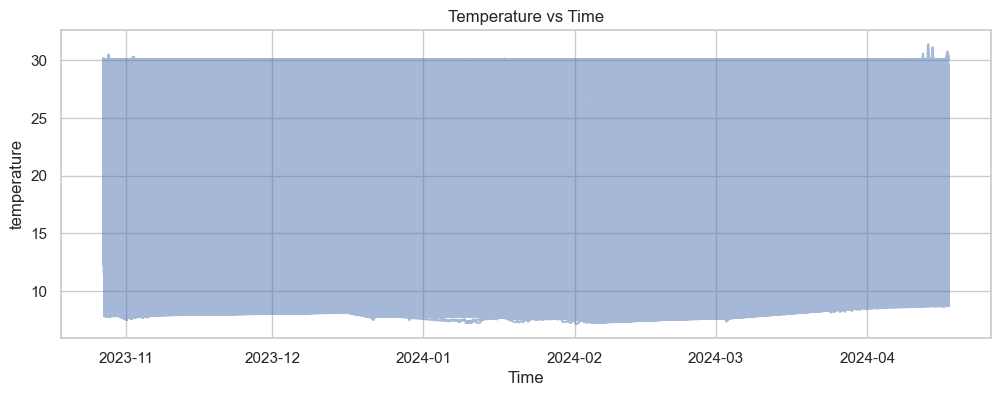

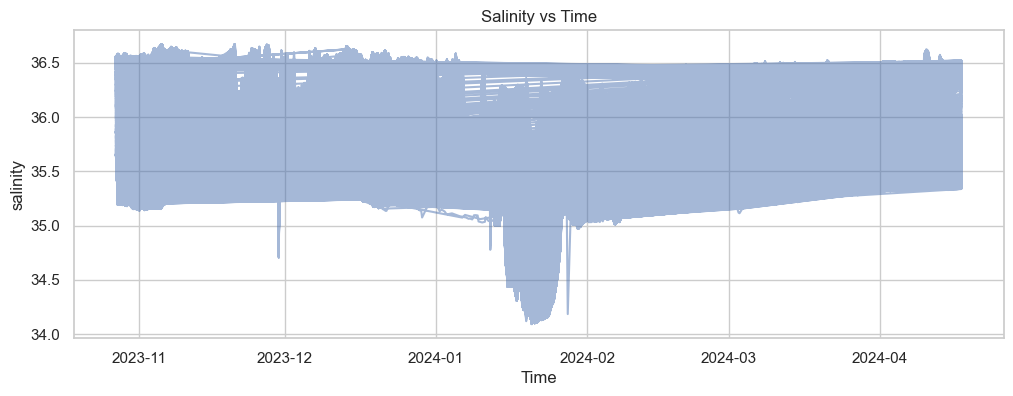

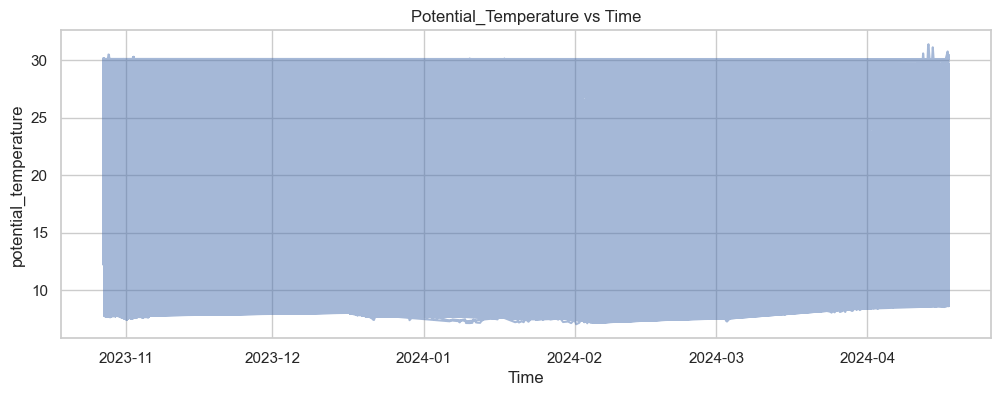

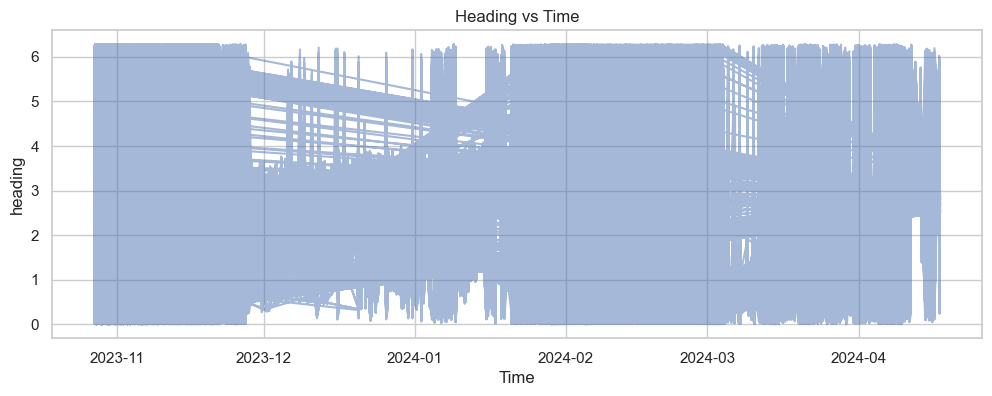

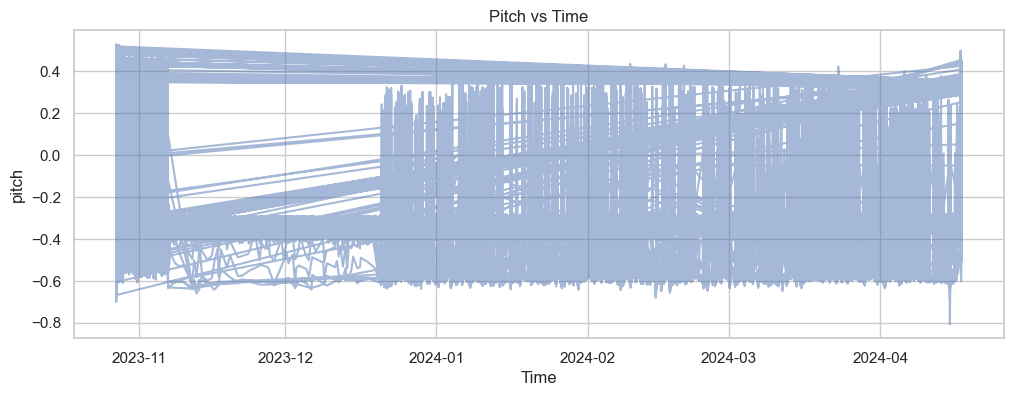

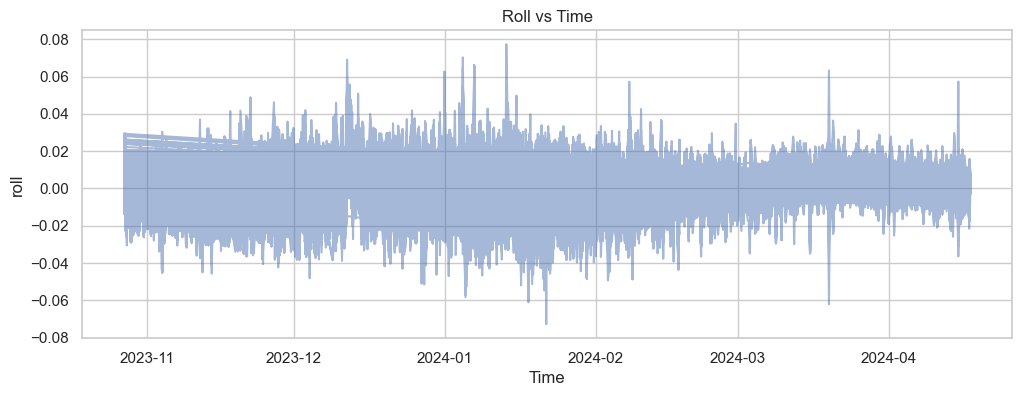


Outlier count per variable (|z| > 3):
temperature                  0
salinity                  2510
potential_temperature        0
heading                      0
pitch                      906
roll                     10354
dtype: int64


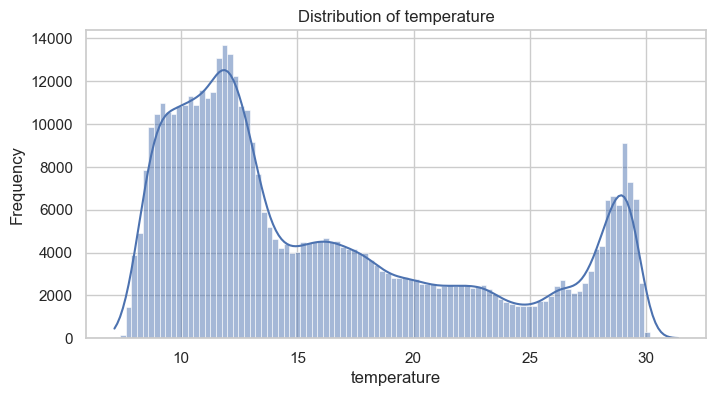

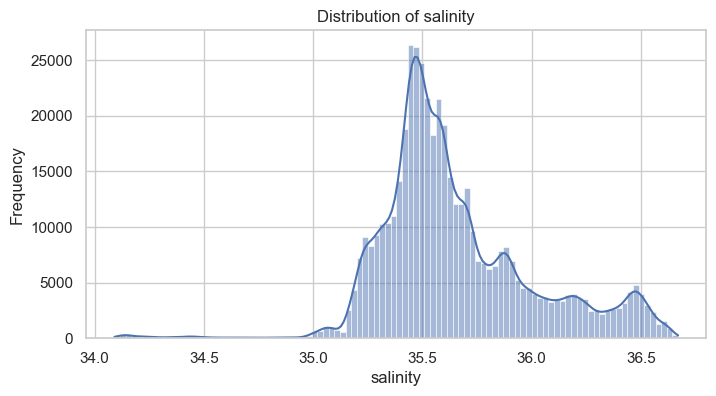

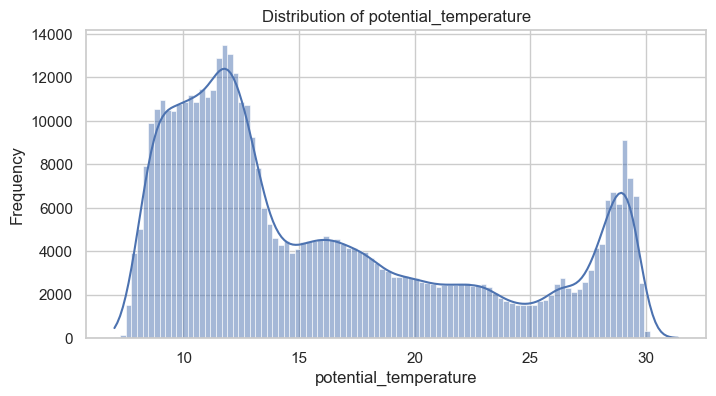

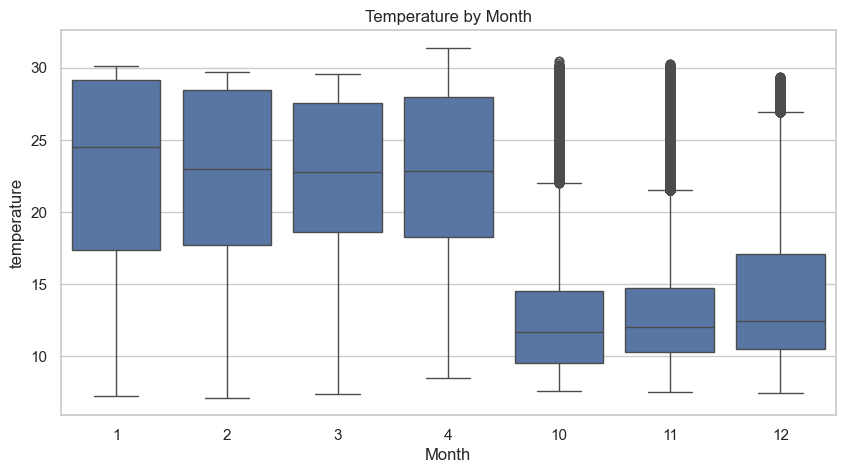

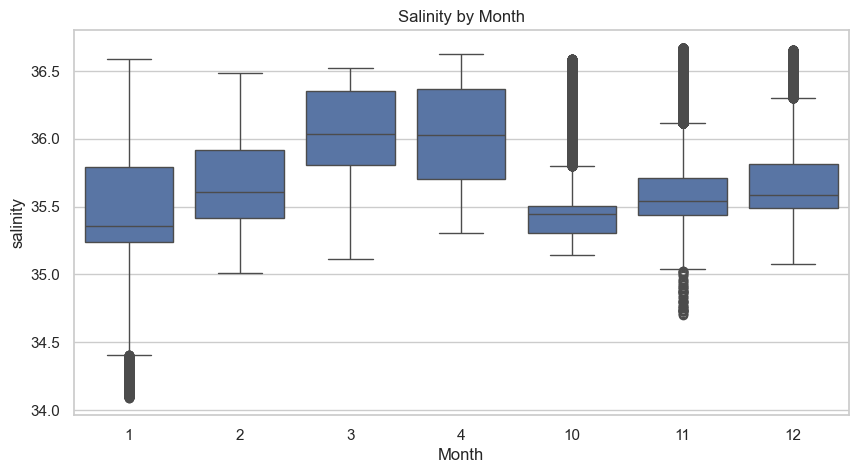

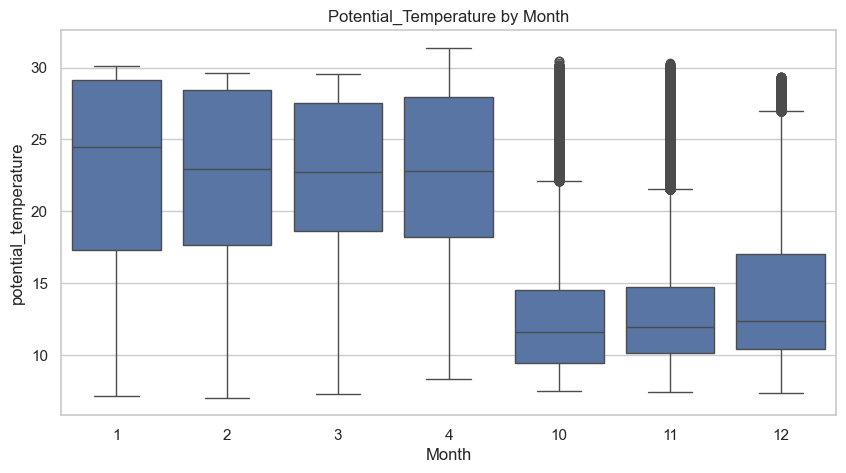

In [13]:
import seaborn as sns
from scipy.stats import zscore

# Extensive Exploratory Data Analysis (EDA) for the NetCDF file and both science & flight sensors

# 1. Dataset Overview
print("Dataset Info:")
print(ds)

print("\nDataset Attributes:")
for key, value in ds.attrs.items():
    print(f"{key}: {value}")

print("\nVariables and Dimensions:")
print("Variables:", list(ds.data_vars))
print("Dimensions:", list(ds.dims))

# 2. Data Completeness
print("\nMissing Values per Variable:")
print(missing)

# 3. Science Sensors Analysis
print("\nScience Variables:", science_vars)
for var in science_vars:
    plt.figure(figsize=(10, 4))
    ds[var].plot()
    plt.title(f'Time Series of {var}')
    plt.xlabel('Time/Depth')
    plt.ylabel(var)
    plt.show()
    plt.figure(figsize=(6, 4))
    ds[var].plot.hist(bins=50)
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

# 4. Flight Sensors Analysis
print("\nFlight Variables:", flight_vars)
for var in flight_vars:
    plt.figure(figsize=(10, 4))
    ds[var].plot()
    plt.title(f'Time Series of {var}')
    plt.xlabel('Time/Depth')
    plt.ylabel(var)
    plt.show()
    plt.figure(figsize=(6, 4))
    ds[var].plot.hist(bins=50)
    plt.title(f'Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

# 5. Correlation Analysis
print("\nCorrelation Matrix (Science & Flight Sensors):")
print(corr)
plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.index)
plt.title('Correlation Matrix')
plt.show()

# 6. Pairwise Scatter Plots (Science vs Flight)
sns.set(style="whitegrid")
pair_vars = science_vars + flight_vars
sample_df = df[pair_vars].sample(n=5000, random_state=42) if len(df) > 5000 else df[pair_vars]
sns.pairplot(sample_df, diag_kind='hist', plot_kws={'alpha':0.3})
plt.suptitle('Pairwise Relationships: Science & Flight Sensors', y=1.02)
plt.show()

# 7. Profile Analysis: Science Sensors vs Depth
for var in science_vars:
    plt.figure(figsize=(8, 6))
    plt.scatter(df.index.get_level_values('depth'), df[var], c=df[var], cmap=cmap, alpha=0.5)
    plt.xlabel('Depth')
    plt.ylabel(var)
    plt.title(f'{var.title()} vs Depth')
    plt.gca().invert_xaxis()
    plt.colorbar(label=var)
    plt.show()

# 8. Profile Analysis: Flight Sensors vs Depth
for var in flight_vars:
    plt.figure(figsize=(8, 6))
    plt.scatter(df.index.get_level_values('depth'), df[var], c=df[var], cmap='coolwarm', alpha=0.5)
    plt.xlabel('Depth')
    plt.ylabel(var)
    plt.title(f'{var.title()} vs Depth')
    plt.gca().invert_xaxis()
    plt.colorbar(label=var)
    plt.show()

# 9. Time Series Analysis: Science & Flight Sensors
for var in science_vars + flight_vars:
    plt.figure(figsize=(12, 4))
    plt.plot(df.index.get_level_values('time'), df[var], alpha=0.5)
    plt.xlabel('Time')
    plt.ylabel(var)
    plt.title(f'{var.title()} vs Time')
    plt.show()

# 10. Outlier Detection
z_scores = df[science_vars + flight_vars].apply(zscore)
outliers = (np.abs(z_scores) > 3).sum()
print("\nOutlier count per variable (|z| > 3):")
print(outliers)

# 11. Distribution Comparison: Science Sensors
for var in science_vars:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[var], bins=100, kde=True)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

# 12. Seasonal/Temporal Trends (if time covers multiple months)
df_time = df.reset_index()
df_time['month'] = df_time['time'].dt.month
for var in science_vars:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='month', y=var, data=df_time)
    plt.title(f'{var.title()} by Month')
    plt.xlabel('Month')
    plt.ylabel(var)
    plt.show()

# 13. Save EDA Results
corr.to_csv('glider_science_flight_correlation.csv')
summary.to_csv('glider_science_flight_summary.csv')

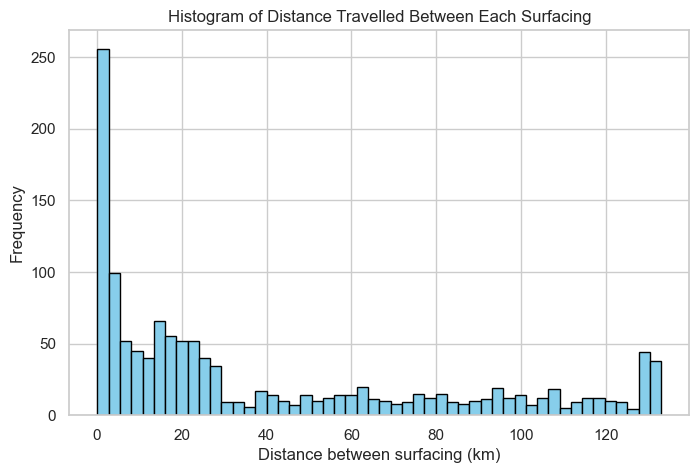

In [16]:
from geopy.distance import geodesic

# Extract surfacing locations (assuming surfacing is at profile_time_start and profile_time_end)
# We'll use profile_time_start, latitude, longitude for each profile
surfacing_df = df_time[['profile_time_start', 'latitude', 'longitude']].drop_duplicates('profile_time_start').sort_values('profile_time_start')

# Compute distances between consecutive surfacing points
distances = []
coords = list(zip(surfacing_df['latitude'], surfacing_df['longitude']))
for i in range(1, len(coords)):
    dist = geodesic(coords[i-1], coords[i]).kilometers
    distances.append(dist)

# Plot histogram of distances
plt.figure(figsize=(8, 5))
plt.hist(distances, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('Distance between surfacing (km)')
plt.ylabel('Frequency')
plt.title('Histogram of Distance Travelled Between Each Surfacing')
plt.show()

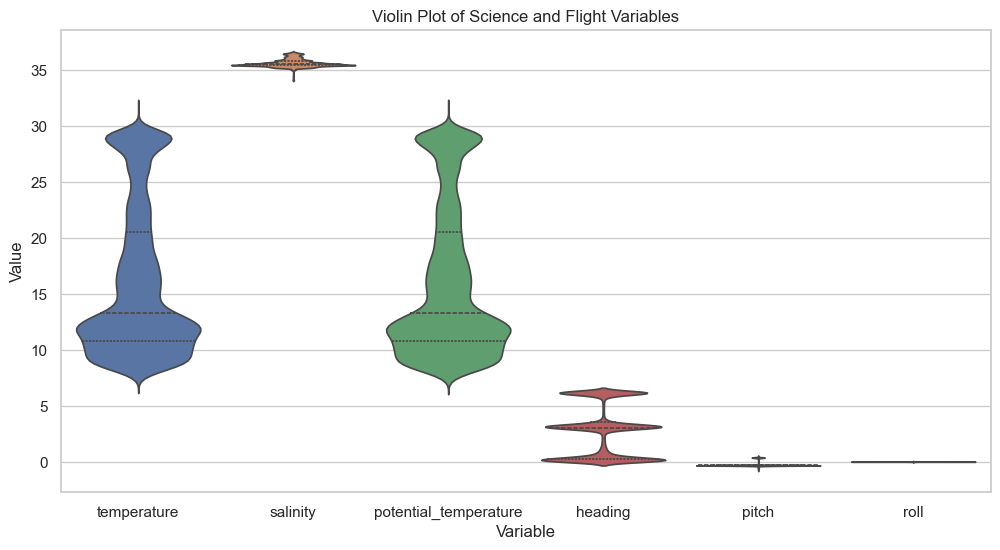

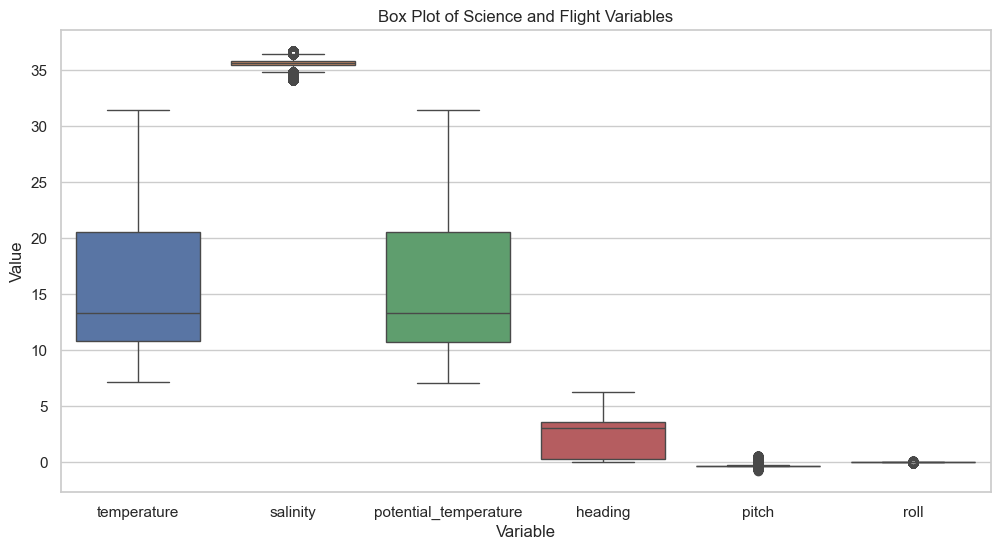

In [17]:
import seaborn as sns

# Violin plot for science and flight variables
plt.figure(figsize=(12, 6))
sns.violinplot(data=df[science_vars + flight_vars], inner='quartile')
plt.title('Violin Plot of Science and Flight Variables')
plt.xlabel('Variable')
plt.ylabel('Value')
plt.show()

# Box plot for science and flight variables
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[science_vars + flight_vars])
plt.title('Box Plot of Science and Flight Variables')
plt.xlabel('Variable')
plt.ylabel('Value')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['latitude'], df['temperature'], c=df['depth'], cmap='plasma', alpha=0.5)
plt.xlabel('Latitude')
plt.ylabel('Temperature')
plt.title('Meridional Transect: Temperature vs Latitude')
plt.colorbar(label='Depth')
plt.show()

In [19]:
plt.figure(figsize=(10, 6))
plt.scatter(df['latitude'], df['salinity'], c=df['depth'], cmap='viridis', alpha=0.5)
plt.xlabel('Latitude')
plt.ylabel('Salinity')
plt.title('Meridional Transect: Salinity vs Latitude')
plt.colorbar(label='Depth')
plt.show()

KeyError: 'depth'

<Figure size 1000x600 with 0 Axes>

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [4]:
file_path_1 = 'D:\\Data\\glider\\process_1127\\L0-timeseries\\dfo-rosie713-20190615.nc'  # Example file path, update as needed

In [ ]:
# Meridional transect: plot Salinity and Temperature vs Latitude

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df['latitude'], df['salinity'], c=df['depth'], cmap='viridis', alpha=0.5)
plt.xlabel('Latitude')
plt.ylabel('Salinity')
plt.title('Meridional Transect: Salinity vs Latitude')
plt.colorbar(label='Depth')

plt.subplot(1, 2, 2)
plt.scatter(df['latitude'], df['temperature'], c=df['depth'], cmap='plasma', alpha=0.5)
plt.xlabel('Latitude')
plt.ylabel('Temperature')
plt.title('Meridional Transect: Temperature vs Latitude')
plt.colorbar(label='Depth')

plt.tight_layout()
plt.show()

# PAR graph (if PAR variable exists)
if 'par' in df.columns:
    plt.figure(figsize=(10, 5))
    plt.scatter(df['depth'], df['par'], c=df['latitude'], cmap='coolwarm', alpha=0.5)
    plt.xlabel('Depth')
    plt.ylabel('PAR')
    plt.title('PAR vs Depth')
    plt.colorbar(label='Latitude')
    plt.show()
else:
    print("PAR variable not found in dataframe.")

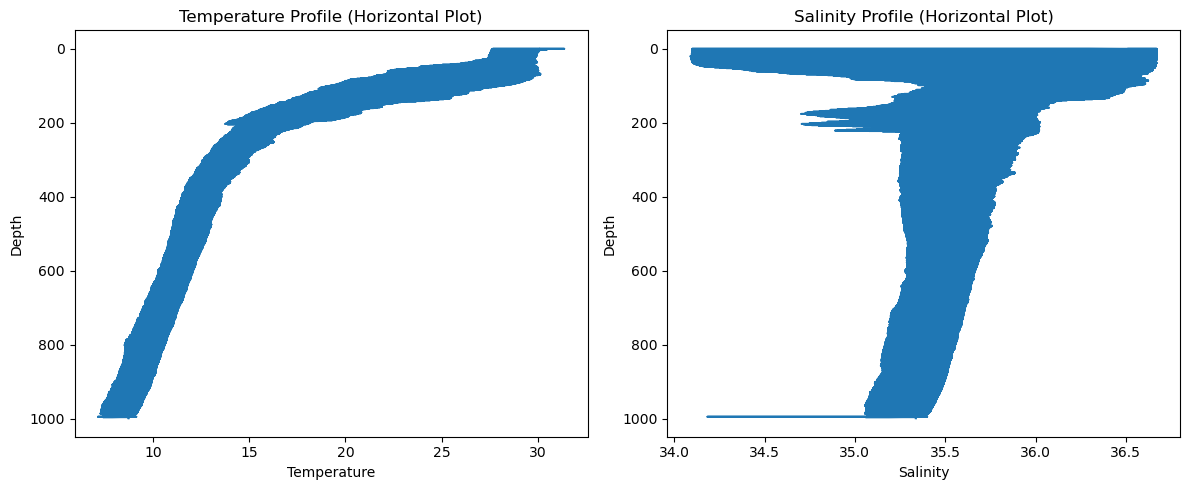

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(df['temperature'], df.index.get_level_values('depth'))
plt.gca().invert_yaxis()
plt.xlabel('Temperature')
plt.ylabel('Depth')
plt.title('Temperature Profile (Horizontal Plot)')

plt.subplot(1, 2, 2)
plt.plot(df['salinity'], df.index.get_level_values('depth'))
plt.gca().invert_yaxis()
plt.xlabel('Salinity')
plt.ylabel('Depth')
plt.title('Salinity Profile (Horizontal Plot)')

plt.tight_layout()
plt.show()

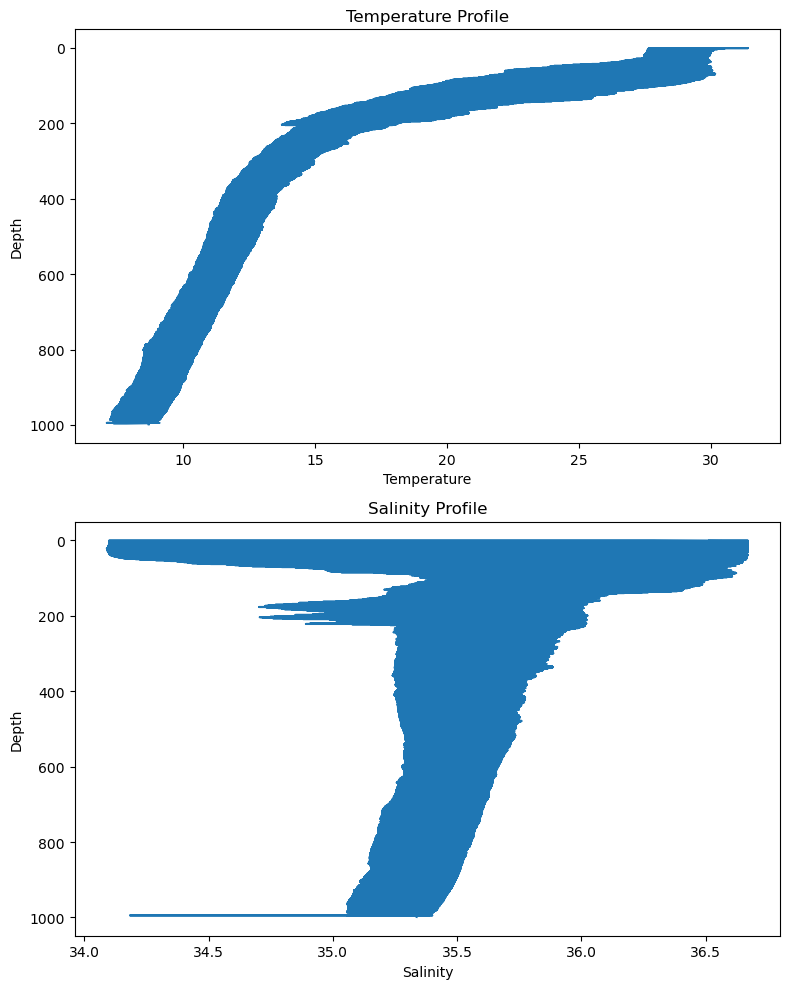

In [8]:
# Two rows and one column configuration for plotting temperature and salinity profiles vs depth

plt.figure(figsize=(8, 10))

plt.subplot(2, 1, 1)
plt.plot(df['temperature'], df.index.get_level_values('depth'))
plt.gca().invert_yaxis()
plt.xlabel('Temperature')
plt.ylabel('Depth')
plt.title('Temperature Profile')

plt.subplot(2, 1, 2)
plt.plot(df['salinity'], df.index.get_level_values('depth'))
plt.gca().invert_yaxis()
plt.xlabel('Salinity')
plt.ylabel('Depth')
plt.title('Salinity Profile')

plt.tight_layout()
plt.show()

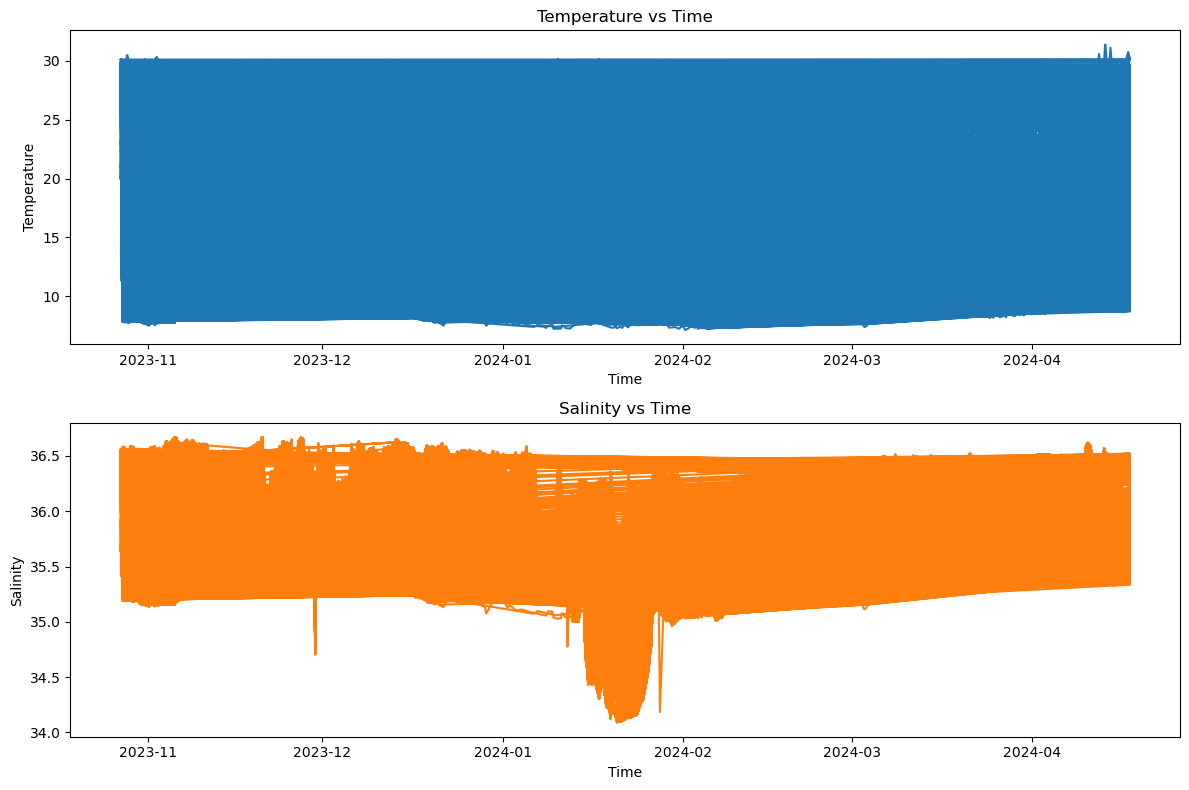

In [10]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(df.index.get_level_values('time'), df['temperature'], color='tab:blue')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.title('Temperature vs Time')

plt.subplot(2, 1, 2)
plt.plot(df.index.get_level_values('time'), df['salinity'], color='tab:orange')
plt.xlabel('Time')
plt.ylabel('Salinity')
plt.title('Salinity vs Time')

plt.tight_layout()
plt.show()

Dataset 1 Overview:
<xarray.Dataset> Size: 735MB
Dimensions:                (time: 4175687)
Coordinates:
  * time                   (time) datetime64[ns] 33MB 2023-10-27T03:43:25 ......
    latitude               (time) float64 33MB ...
    longitude              (time) float64 33MB ...
    depth                  (time) float64 33MB ...
Data variables: (12/18)
    heading                (time) float64 33MB ...
    pitch                  (time) float64 33MB ...
    roll                   (time) float64 33MB ...
    waypoint_latitude      (time) float64 33MB ...
    waypoint_longitude     (time) float64 33MB ...
    conductivity           (time) float64 33MB ...
    ...                     ...
    salinity               (time) float64 33MB ...
    potential_density      (time) float64 33MB ...
    density                (time) float64 33MB ...
    potential_temperature  (time) float64 33MB ...
    profile_index          (time) float64 33MB ...
    profile_direction      (time) float64 33

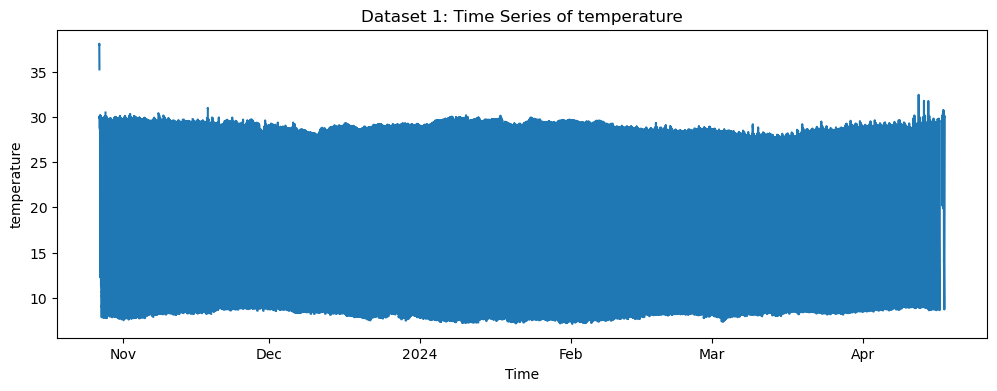

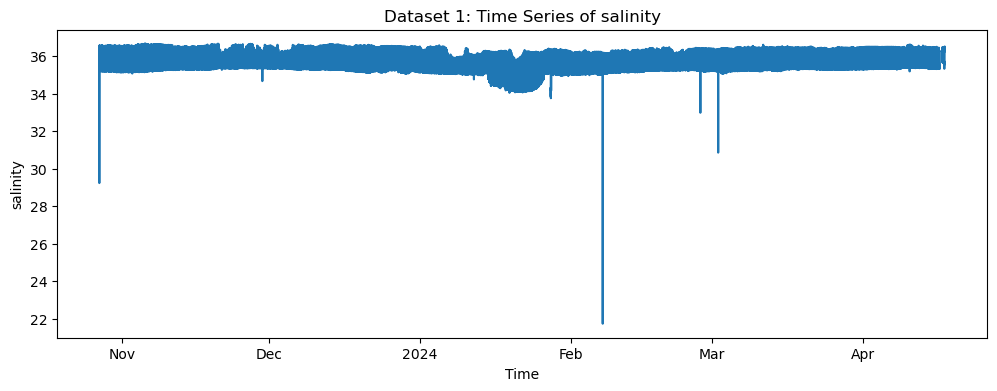

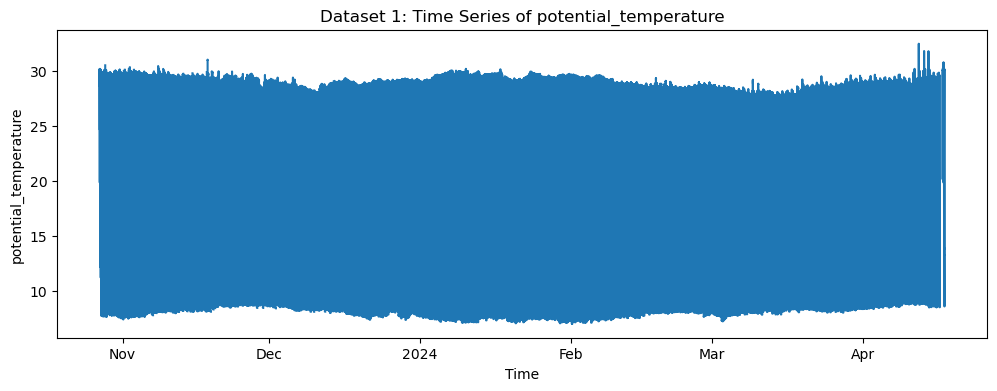

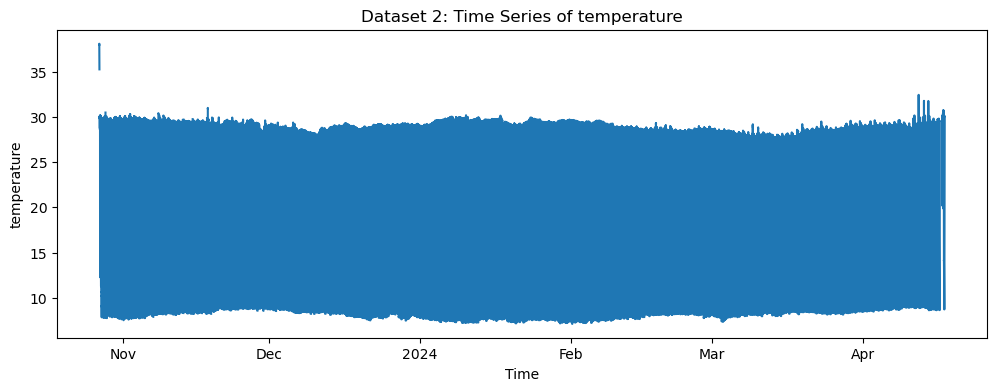

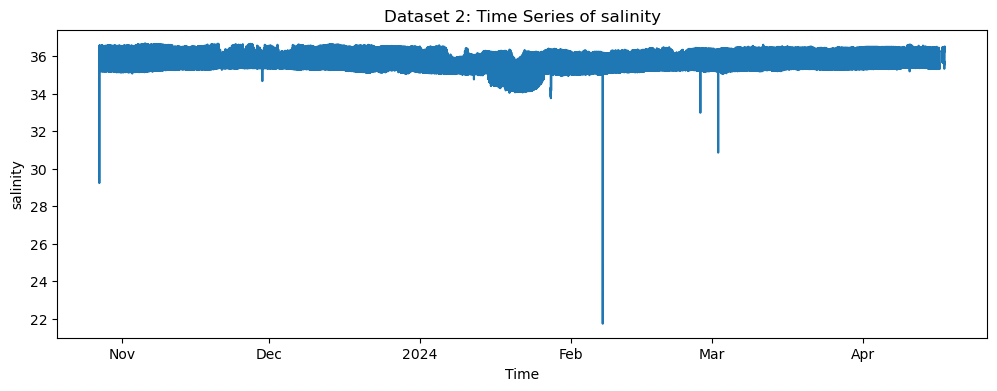

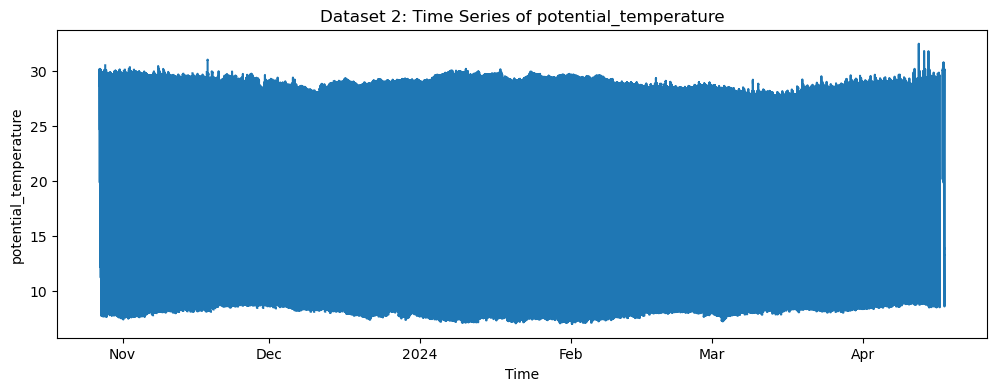

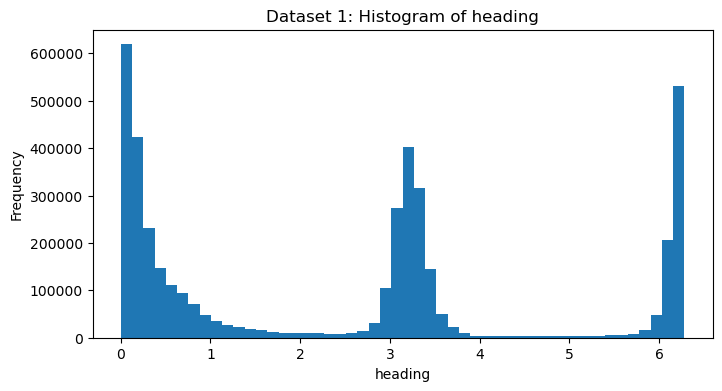

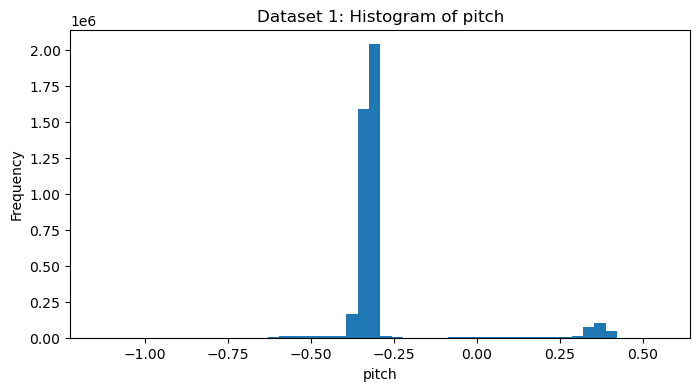

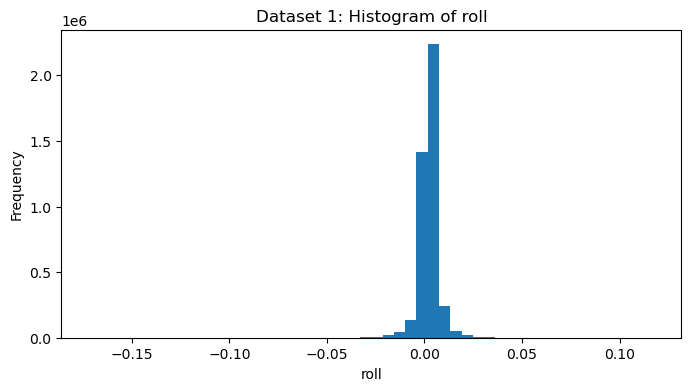

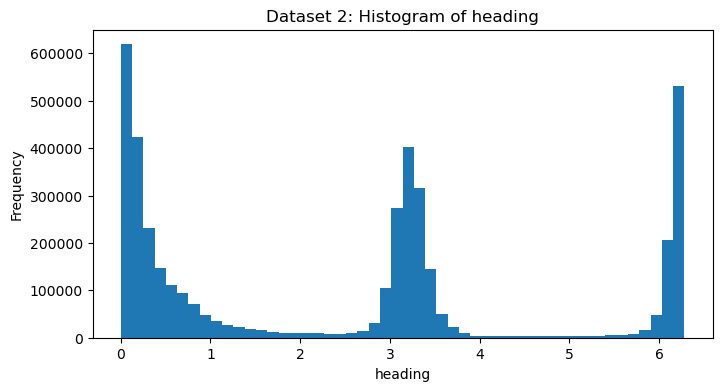

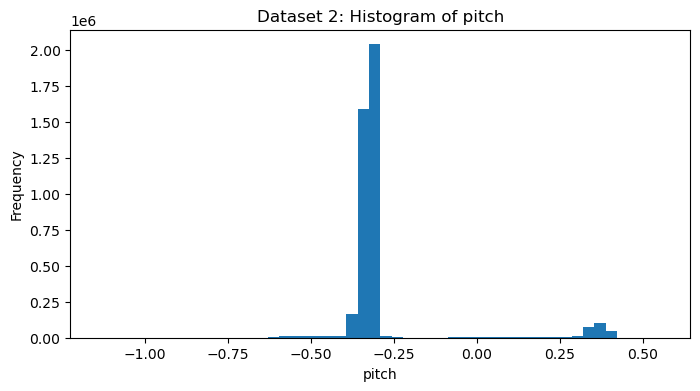

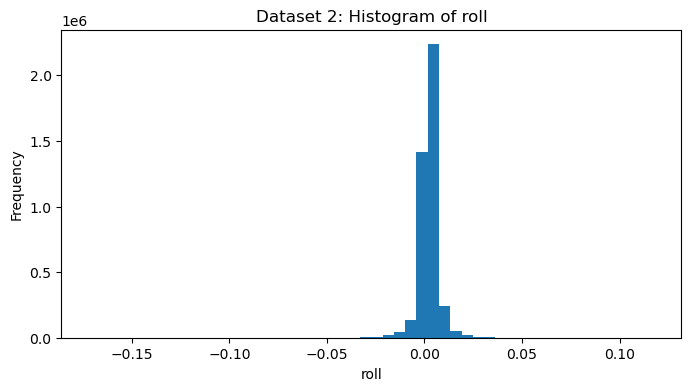

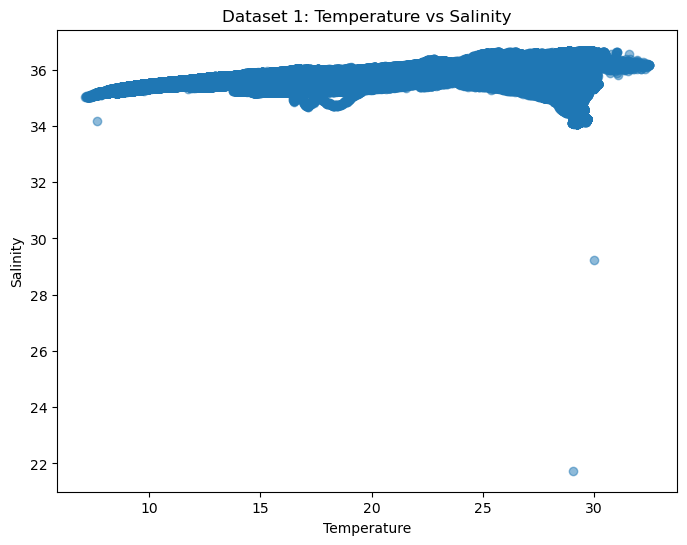

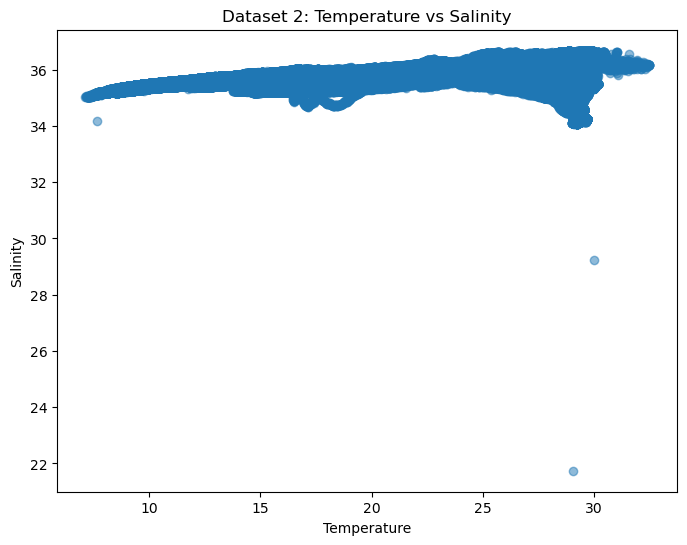

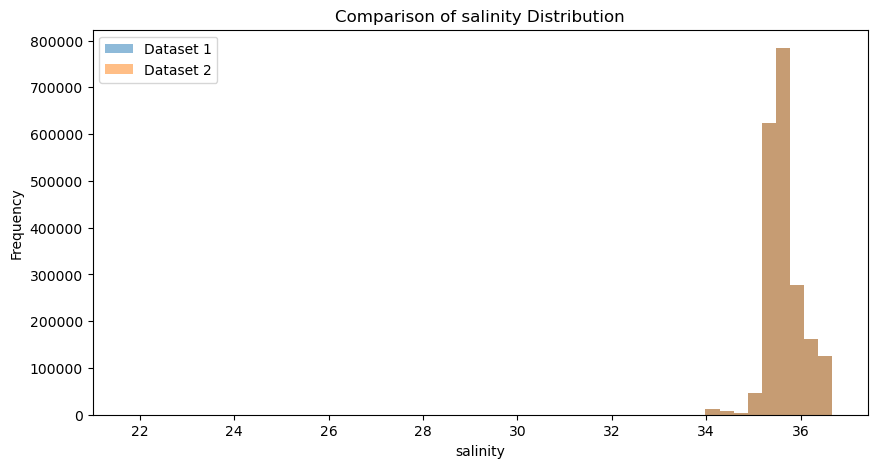

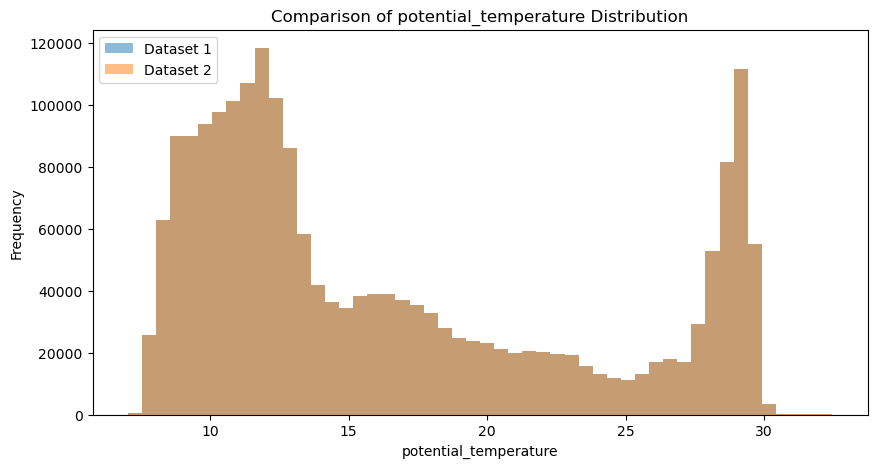

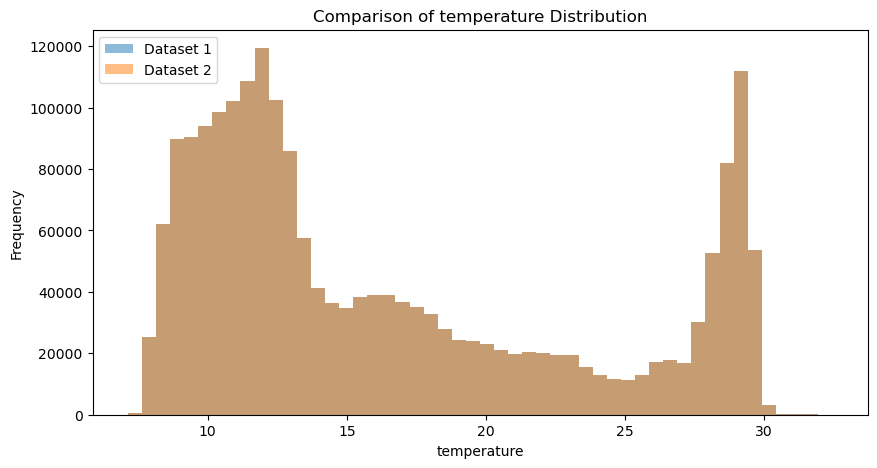

In [11]:
# Load both NetCDF files
ds1 = xr.open_dataset(file_path_1)
ds2 = xr.open_dataset(file_path)

# Print basic info for both datasets
print("Dataset 1 Overview:")
print(ds1)
print("\nDataset 2 Overview:")
print(ds2)

# List variables and dimensions for both datasets
print("\nVariables in Dataset 1:", list(ds1.data_vars))
print("Dimensions in Dataset 1:", list(ds1.dims))
print("\nVariables in Dataset 2:", list(ds2.data_vars))
print("Dimensions in Dataset 2:", list(ds2.dims))

# Convert to DataFrames for analysis
df1 = ds1.to_dataframe().dropna()
df2 = ds2.to_dataframe().dropna()

# Summary statistics
print("\nSummary statistics for Dataset 1:")
print(df1.describe())
print("\nSummary statistics for Dataset 2:")
print(df2.describe())

# Missing values
print("\nMissing values in Dataset 1:")
print(ds1.to_dataframe().isnull().sum())
print("\nMissing values in Dataset 2:")
print(ds2.to_dataframe().isnull().sum())

# Correlation analysis
science_vars_1 = [var for var in ds1.data_vars if 'temperature' in var or 'salinity' in var or 'potential_temperature' in var]
flight_vars_1 = [var for var in ds1.data_vars if 'pitch' in var or 'roll' in var or 'heading' in var]
corr1 = df1[science_vars_1 + flight_vars_1].corr()
print("\nCorrelation matrix for Dataset 1:\n", corr1)

science_vars_2 = [var for var in ds2.data_vars if 'temperature' in var or 'salinity' in var or 'potential_temperature' in var]
flight_vars_2 = [var for var in ds2.data_vars if 'pitch' in var or 'roll' in var or 'heading' in var]
corr2 = df2[science_vars_2 + flight_vars_2].corr()
print("\nCorrelation matrix for Dataset 2:\n", corr2)

# Plot time series for key science sensors
for var in science_vars_1:
    plt.figure(figsize=(12, 4))
    ds1[var].plot()
    plt.title(f'Dataset 1: Time Series of {var}')
    plt.xlabel('Time')
    plt.ylabel(var)
    plt.show()

for var in science_vars_2:
    plt.figure(figsize=(12, 4))
    ds2[var].plot()
    plt.title(f'Dataset 2: Time Series of {var}')
    plt.xlabel('Time')
    plt.ylabel(var)
    plt.show()

# Plot histograms for flight parameters
for var in flight_vars_1:
    plt.figure(figsize=(8, 4))
    ds1[var].plot.hist(bins=50)
    plt.title(f'Dataset 1: Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

for var in flight_vars_2:
    plt.figure(figsize=(8, 4))
    ds2[var].plot.hist(bins=50)
    plt.title(f'Dataset 2: Histogram of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.show()

# Scatter plots: temperature vs salinity
if 'temperature' in df1.columns and 'salinity' in df1.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(df1['temperature'], df1['salinity'], alpha=0.5)
    plt.xlabel('Temperature')
    plt.ylabel('Salinity')
    plt.title('Dataset 1: Temperature vs Salinity')
    plt.show()

if 'temperature' in df2.columns and 'salinity' in df2.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(df2['temperature'], df2['salinity'], alpha=0.5)
    plt.xlabel('Temperature')
    plt.ylabel('Salinity')
    plt.title('Dataset 2: Temperature vs Salinity')
    plt.show()

# Compare distributions between datasets
for var in set(science_vars_1).intersection(science_vars_2):
    plt.figure(figsize=(10, 5))
    plt.hist(df1[var], bins=50, alpha=0.5, label='Dataset 1')
    plt.hist(df2[var], bins=50, alpha=0.5, label='Dataset 2')
    plt.xlabel(var)
    plt.ylabel('Frequency')
    plt.title(f'Comparison of {var} Distribution')
    plt.legend()
    plt.show()

# Save summary statistics and correlations to CSV
df1.describe().to_csv('glider_data1_summary.csv')
df2.describe().to_csv('glider_data2_summary.csv')
corr1.to_csv('glider_data1_correlation.csv')
corr2.to_csv('glider_data2_correlation.csv')

In [ ]:
# Example: Plot temperature, salinity, DO, and chlorophyll-a with suitable colormaps

variables_to_plot = {
    'temperature': 'plasma',
    'salinity': 'viridis',
    'oxygen_concentration': 'Blues',
    'chlorophyll': 'YlGn'
}

for var, cmap in variables_to_plot.items():
    if var in df.columns:
        plt.figure(figsize=(10, 5))
        sc = plt.scatter(df['depth'], df[var], c=df[var], cmap=cmap, alpha=0.5)
        plt.xlabel('Depth')
        plt.ylabel(var.replace('_', ' ').title())
        plt.title(f'{var.replace("_", " ").title()} vs Depth')
        plt.colorbar(sc, label=var.replace('_', ' ').title())
        plt.gca().invert_xaxis() if 'depth' in df.columns else None
        plt.show()
    else:
        print(f"{var} not found in dataframe.")